🚀 BẮT ĐẦU CHẠY PIPELINE PHÂN TÍCH TRỰC QUAN (8 BIỂU ĐỒ)...
📊 1/8. Đang vẽ biểu đồ phân phối dữ liệu...


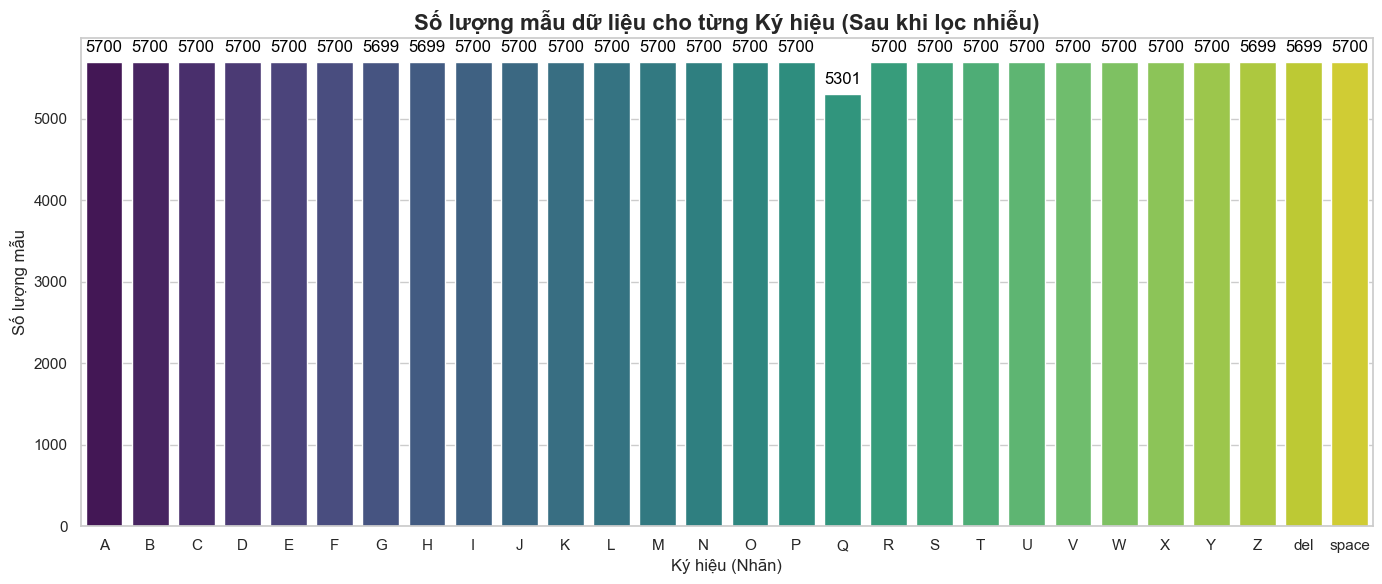

🧹 2/8. Đang phân tích tác động lọc nhiễu...


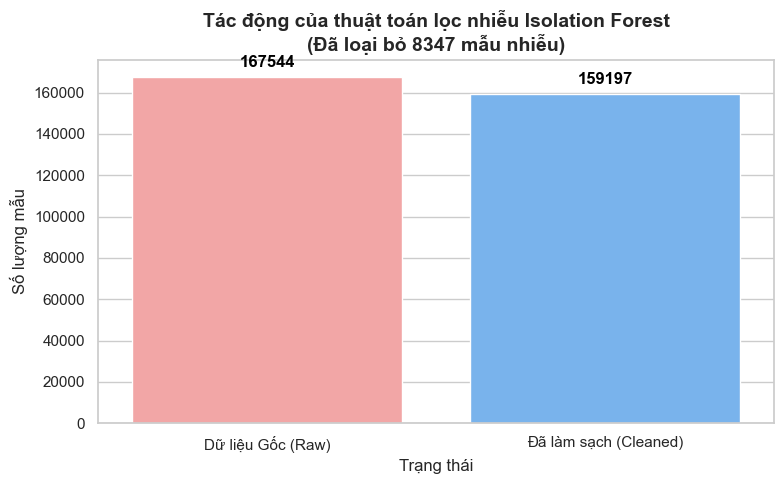

🧠 3/8. Đang huấn luyện mô hình để vẽ Ma trận nhầm lẫn...


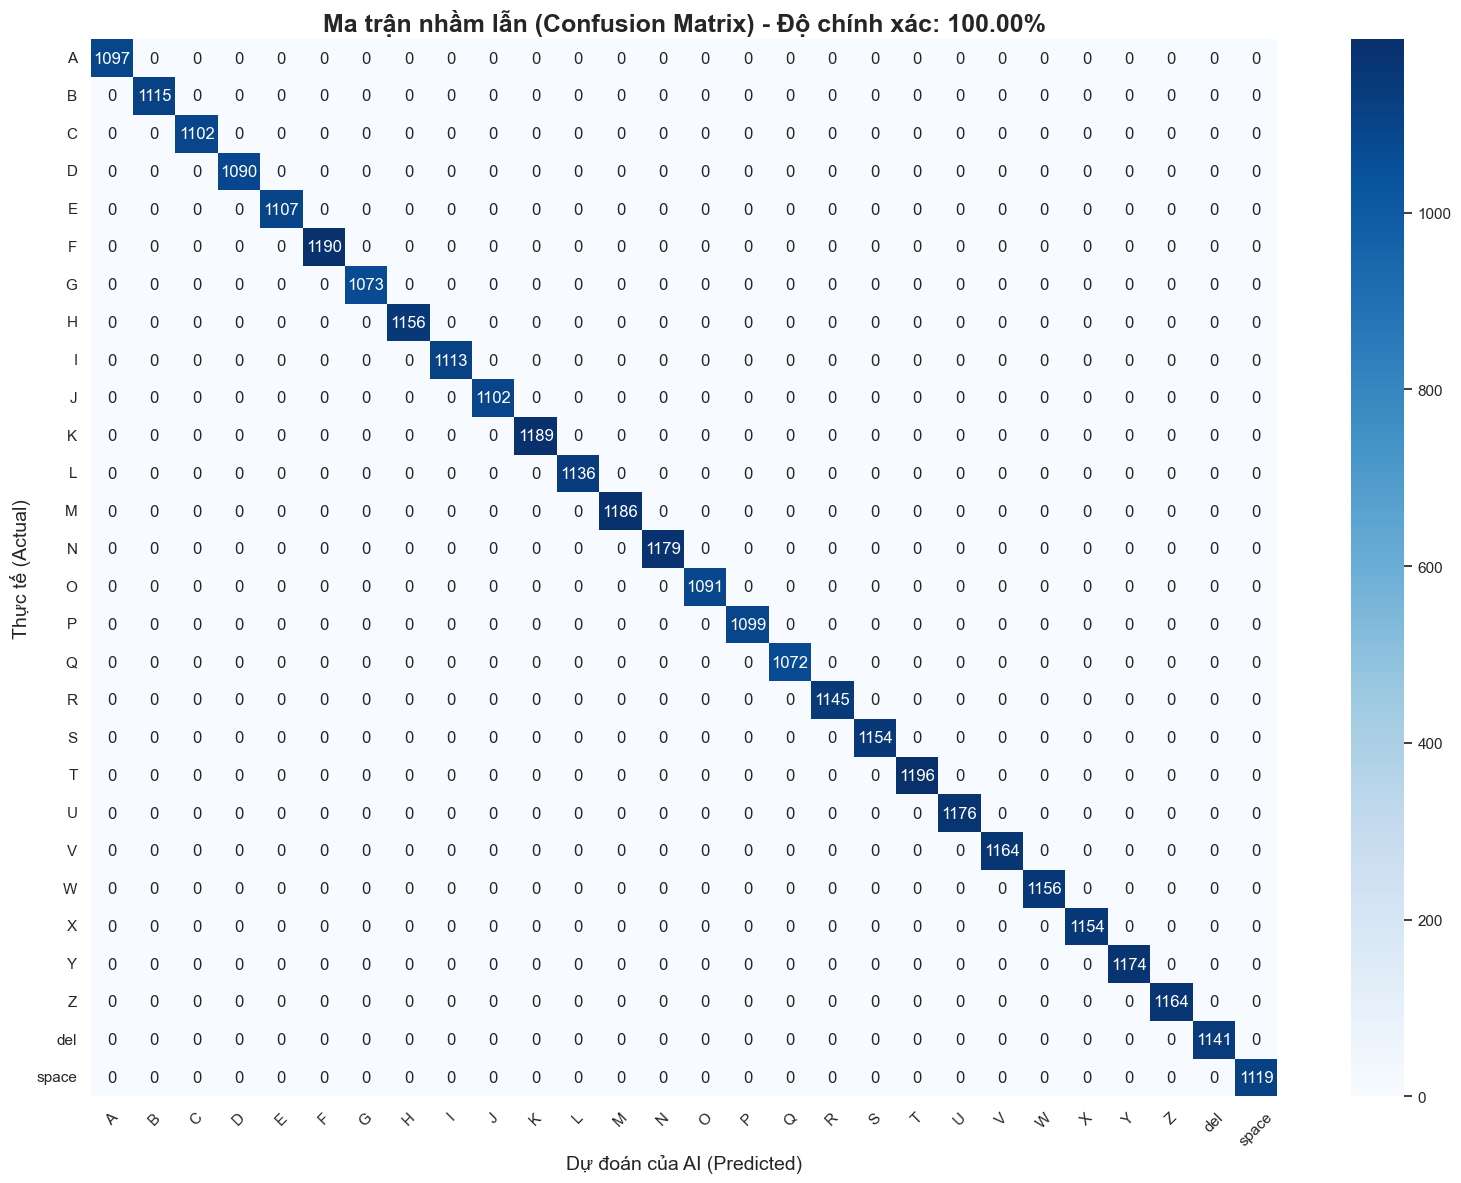

🌟 4/8. Đang phân tích mức độ quan trọng của đặc trưng...


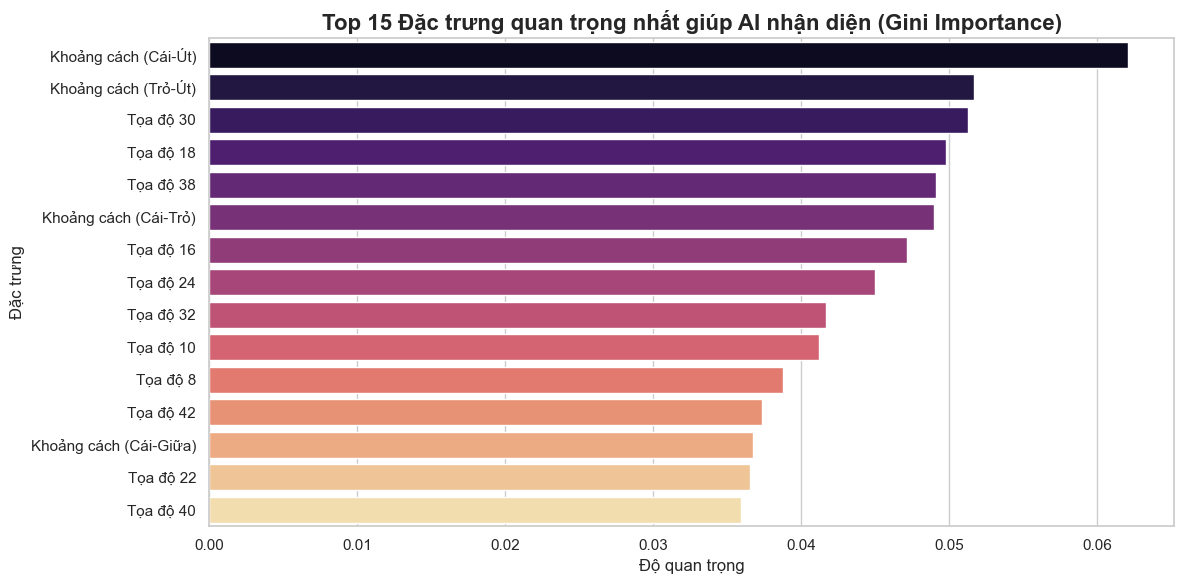

🥊 5/8. Đang so sánh hiệu năng các thuật toán Machine Learning...


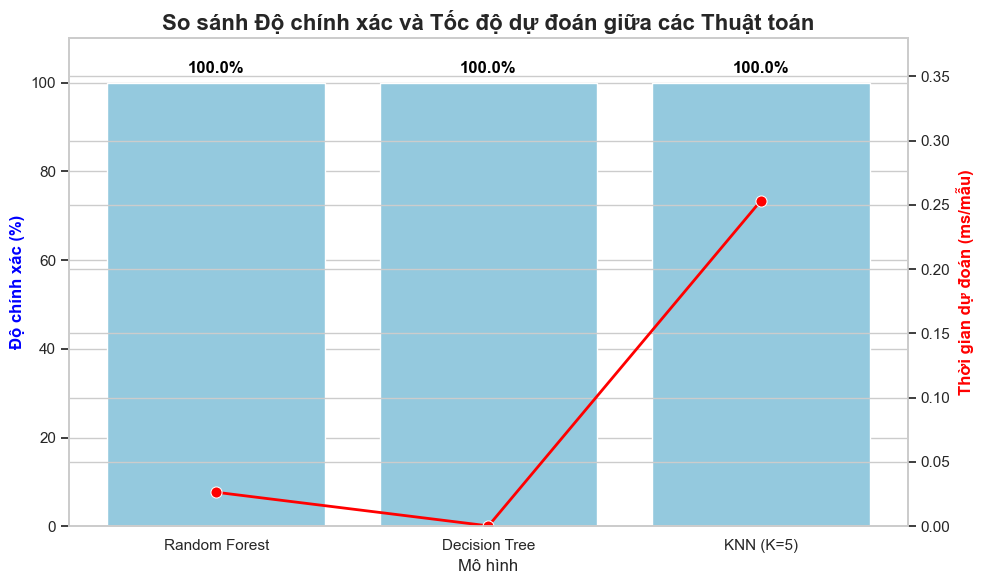

🌌 6/8. Đang giảm chiều dữ liệu từ 51D xuống 2D bằng thuật toán PCA...


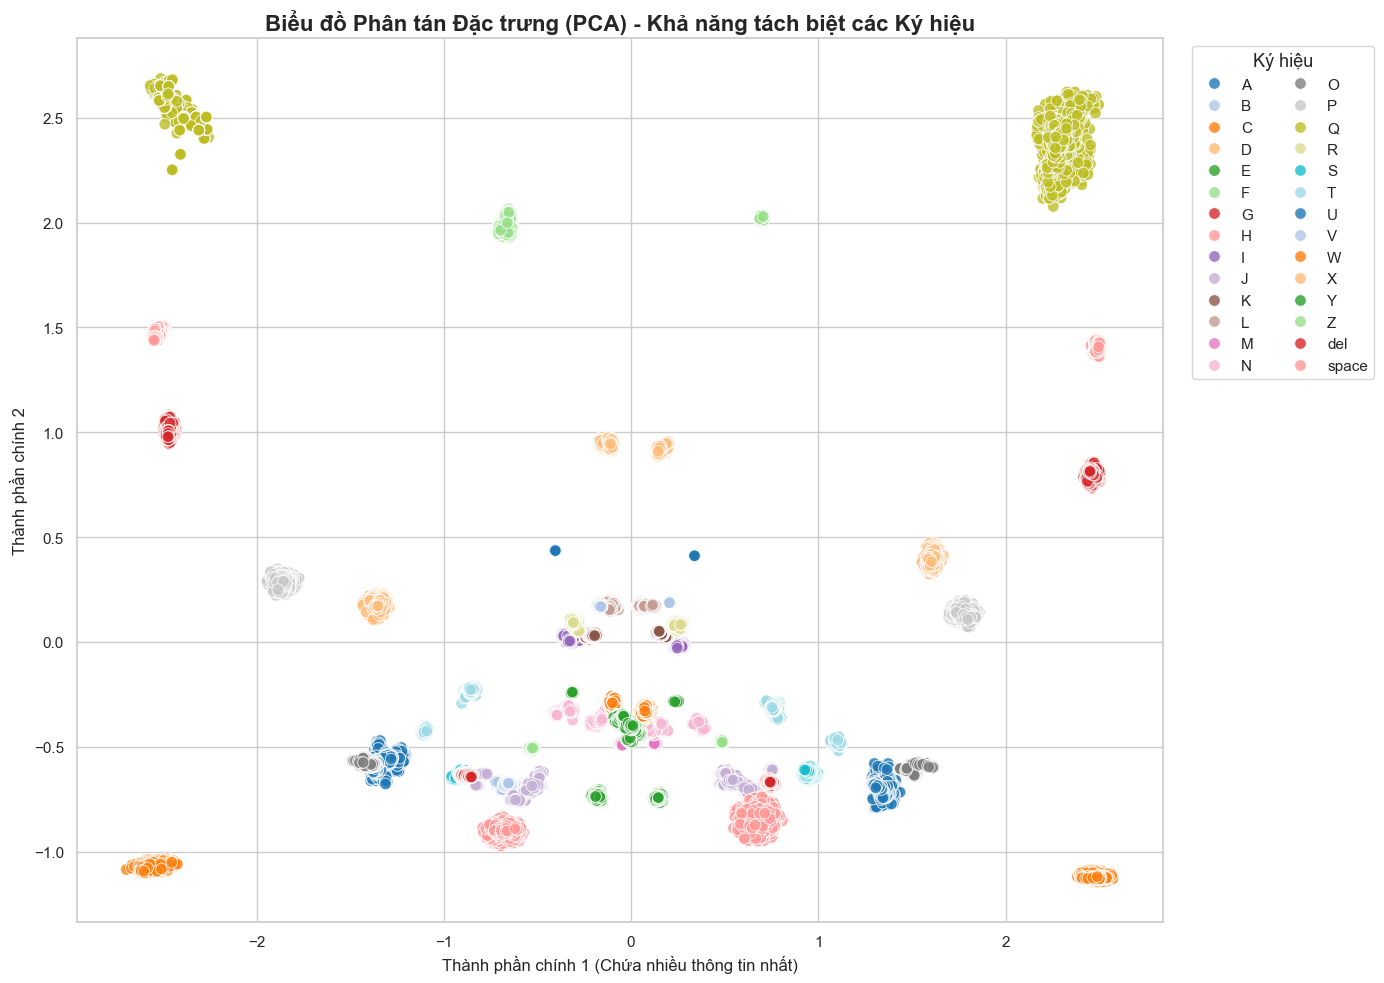

📦 7/8. Đang vẽ Biểu đồ Hộp phân tích khoảng cách Ngón Cái - Ngón Trỏ...


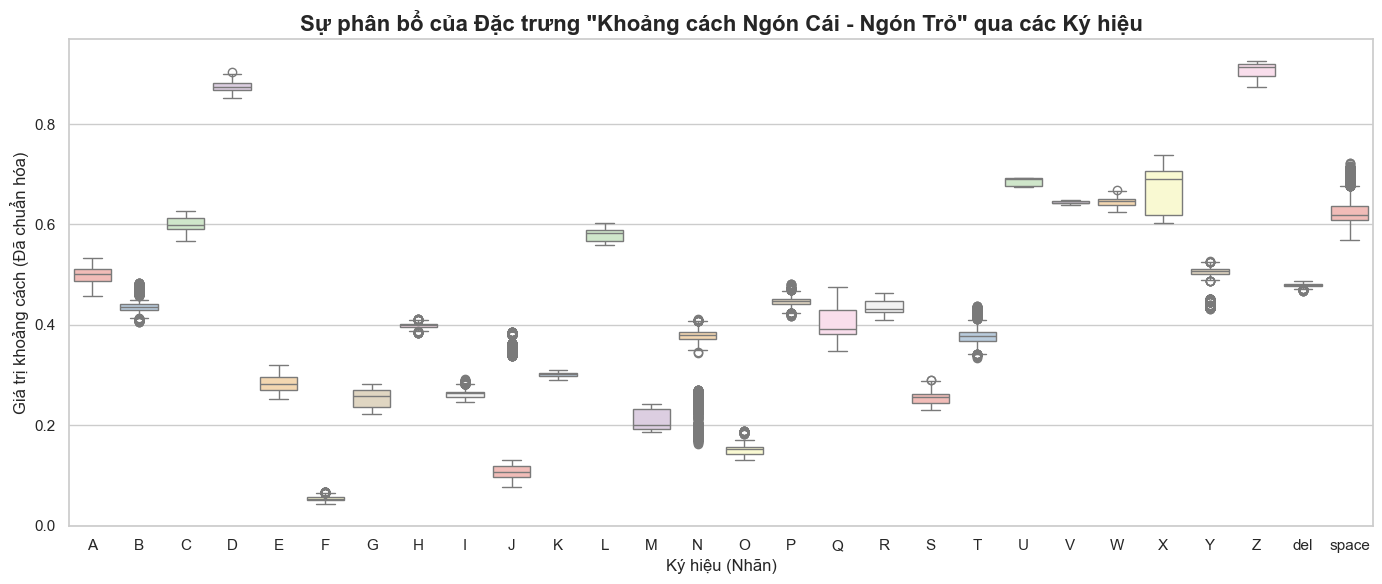

📈 8/8. Đang chạy Cross-validation để vẽ Đường cong học tập...


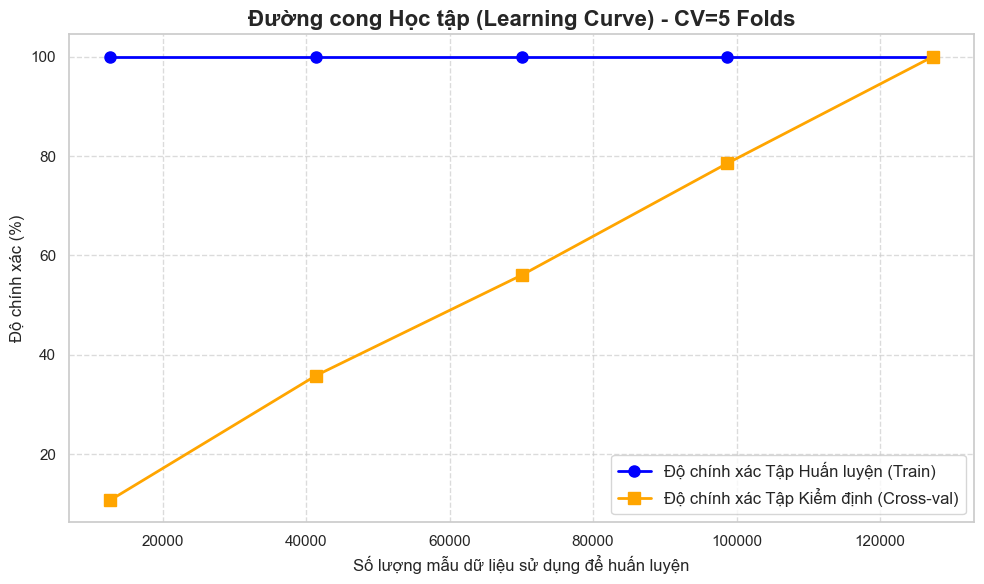

✅ ĐÃ HOÀN TẤT XUẤT 8 BIỂU ĐỒ BÁO CÁO CHUYÊN SÂU! BRO CÓ THỂ CHỤP LƯU LẠI RỒI.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
import warnings

# Tắt các cảnh báo lặt vặt của thư viện
warnings.filterwarnings('ignore')

# Thiết lập phong cách vẽ biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

def run_all_visualizations():
    print("🚀 BẮT ĐẦU CHẠY PIPELINE PHÂN TÍCH TRỰC QUAN (8 BIỂU ĐỒ)...")
    
    # 1. KIỂM TRA VÀ LOAD DỮ LIỆU
    raw_data_path = os.path.join('..', 'data', 'hand_data_all.csv')
    clean_data_path = os.path.join('..', 'data', 'cleaned_data.csv')
    
    if not os.path.exists(clean_data_path):
        print("❌ LỖI: Không tìm thấy file cleaned_data.csv!")
        return

    df_clean = pd.read_csv(clean_data_path, header=None)
    
    # FIX LỖI "INT IS NOT ITERABLE": Đặt tên cột đàng hoàng bằng chữ thay vì số
    col_names = ['Label'] + [f'Feature_{i}' for i in range(1, df_clean.shape[1])]
    df_clean.columns = col_names
    
    # Ép kiểu dữ liệu an toàn
    X = np.asarray(df_clean.iloc[:, 1:].values, dtype=np.float32)
    y = np.asarray(df_clean['Label'].values, dtype=str)
    order = sorted(list(set(y)))
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # =====================================================================
    # BIỂU ĐỒ 1: PHÂN PHỐI DỮ LIỆU
    # =====================================================================
    print("📊 1/8. Đang vẽ biểu đồ phân phối dữ liệu...")
    plt.figure(figsize=(14, 6))
    ax1 = sns.countplot(data=df_clean, x='Label', order=order, palette='viridis', hue='Label')
    if ax1.legend_ is not None:
        ax1.legend_.remove()
        
    plt.title('Số lượng mẫu dữ liệu cho từng Ký hiệu (Sau khi lọc nhiễu)', fontsize=16, fontweight='bold')
    plt.xlabel('Ký hiệu (Nhãn)', fontsize=12)
    plt.ylabel('Số lượng mẫu', fontsize=12)
    for p in ax1.patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            ax1.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', color='black', xytext=(0, 5), textcoords='offset points')
    plt.tight_layout()
    plt.show()

    # =====================================================================
    # BIỂU ĐỒ 2: TÁC ĐỘNG CỦA BỘ LỌC NHIỄU
    # =====================================================================
    if os.path.exists(raw_data_path):
        print("🧹 2/8. Đang phân tích tác động lọc nhiễu...")
        df_raw = pd.read_csv(raw_data_path, header=None)
        stats = pd.DataFrame({
            'Trạng thái': ['Dữ liệu Gốc (Raw)', 'Đã làm sạch (Cleaned)'],
            'Số lượng mẫu': [len(df_raw), len(df_clean)]
        })
        
        plt.figure(figsize=(8, 5))
        ax2 = sns.barplot(data=stats, x='Trạng thái', y='Số lượng mẫu', hue='Trạng thái', palette=['#ff9999', '#66b3ff'])
        if ax2.legend_ is not None:
            ax2.legend_.remove()
            
        plt.title(f'Tác động của thuật toán lọc nhiễu Isolation Forest\n(Đã loại bỏ {len(df_raw) - len(df_clean)} mẫu nhiễu)', fontsize=14, fontweight='bold')
        for p in ax2.patches:
            height = p.get_height()
            if not np.isnan(height) and height > 0:
                ax2.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='bottom', color='black', xytext=(0, 5), textcoords='offset points', fontweight='bold')
        plt.tight_layout()
        plt.show()

    # =====================================================================
    # BIỂU ĐỒ 3: MA TRẬN NHẦM LẪN
    # =====================================================================
    print("🧠 3/8. Đang huấn luyện mô hình để vẽ Ma trận nhầm lẫn...")
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred, labels=order)
    plt.figure(figsize=(16, 12))
    
    ax_hm = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    ax_hm.set_xticks(np.arange(len(order)) + 0.5)
    ax_hm.set_yticks(np.arange(len(order)) + 0.5)
    ax_hm.set_xticklabels(order, rotation=45)
    ax_hm.set_yticklabels(order, rotation=0)
    
    plt.title(f'Ma trận nhầm lẫn (Confusion Matrix) - Độ chính xác: {accuracy_score(y_test, y_pred)*100:.2f}%', fontsize=18, fontweight='bold')
    plt.xlabel('Dự đoán của AI (Predicted)', fontsize=14)
    plt.ylabel('Thực tế (Actual)', fontsize=14)
    plt.tight_layout()
    plt.show()

    # =====================================================================
    # BIỂU ĐỒ 4: MỨC ĐỘ QUAN TRỌNG CỦA ĐẶC TRƯNG
    # =====================================================================
    print("🌟 4/8. Đang phân tích mức độ quan trọng của đặc trưng...")
    importances = rf_model.feature_importances_
    
    feature_names = [f'Tọa độ {i}' for i in range(1, 43)] + \
                    ['Khoảng cách (Cái-Trỏ)', 'Khoảng cách (Cái-Giữa)', 'Khoảng cách (Cái-Út)', 'Khoảng cách (Trỏ-Út)'] + \
                    ['Góc (Ngón cái)', 'Góc (Ngón trỏ)', 'Góc (Ngón giữa)', 'Góc (Ngón áp út)', 'Góc (Ngón út)']
    
    if len(feature_names) != len(importances):
        feature_names = [f'Đặc trưng {i}' for i in range(1, len(importances) + 1)]

    feat_df = pd.DataFrame({'Đặc trưng': feature_names, 'Độ quan trọng': importances})
    feat_df = feat_df.sort_values(by='Độ quan trọng', ascending=False).head(15)

    plt.figure(figsize=(12, 6))
    ax4 = sns.barplot(data=feat_df, x='Độ quan trọng', y='Đặc trưng', hue='Đặc trưng', palette='magma')
    if ax4.legend_ is not None:
        ax4.legend_.remove()
        
    plt.title('Top 15 Đặc trưng quan trọng nhất giúp AI nhận diện (Gini Importance)', fontsize=16, fontweight='bold')
    plt.xlabel('Độ quan trọng', fontsize=12)
    plt.ylabel('Đặc trưng', fontsize=12)
    plt.tight_layout()
    plt.show()

    # =====================================================================
    # BIỂU ĐỒ 5: SO SÁNH ĐA MÔ HÌNH
    # =====================================================================
    print("🥊 5/8. Đang so sánh hiệu năng các thuật toán Machine Learning...")
    models = {
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'KNN (K=5)': KNeighborsClassifier(n_neighbors=5)
    }
    
    results = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        start_time = time.time()
        preds = model.predict(X_test)
        end_time = time.time()
        
        acc = accuracy_score(y_test, preds) * 100
        inf_time = (end_time - start_time) / len(X_test) * 1000 
        results.append({'Mô hình': name, 'Độ chính xác (%)': acc, 'Thời gian dự đoán (ms/mẫu)': inf_time})
        
    df_results = pd.DataFrame(results)

    fig, ax5 = plt.subplots(figsize=(10, 6))
    sns.barplot(data=df_results, x='Mô hình', y='Độ chính xác (%)', ax=ax5, color='skyblue')
    ax5.set_ylim(0, 110)
    ax5.set_ylabel('Độ chính xác (%)', color='blue', fontsize=12, fontweight='bold')
    for p in ax5.patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            ax5.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', color='black', xytext=(0, 5), textcoords='offset points', fontweight='bold')

    ax6 = ax5.twinx()
    sns.lineplot(data=df_results, x='Mô hình', y='Thời gian dự đoán (ms/mẫu)', ax=ax6, color='red', marker='o', linewidth=2, markersize=8)
    ax6.set_ylabel('Thời gian dự đoán (ms/mẫu)', color='red', fontsize=12, fontweight='bold')
    ax6.set_ylim(0, df_results['Thời gian dự đoán (ms/mẫu)'].max() * 1.5)

    plt.title('So sánh Độ chính xác và Tốc độ dự đoán giữa các Thuật toán', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # =====================================================================
    # BIỂU ĐỒ 6: PHÂN TÁN KHÔNG GIAN ĐẶC TRƯNG (PCA)
    # =====================================================================
    print("🌌 6/8. Đang giảm chiều dữ liệu từ 51D xuống 2D bằng thuật toán PCA...")
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    
    plt.figure(figsize=(14, 10))
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='tab20', s=70, alpha=0.8)
    plt.title('Biểu đồ Phân tán Đặc trưng (PCA) - Khả năng tách biệt các Ký hiệu', fontsize=16, fontweight='bold')
    plt.xlabel('Thành phần chính 1 (Chứa nhiều thông tin nhất)', fontsize=12)
    plt.ylabel('Thành phần chính 2', fontsize=12)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=2, title="Ký hiệu", title_fontsize='13', fontsize='11')
    plt.tight_layout()
    plt.show()

    # =====================================================================
    # BIỂU ĐỒ 7: BIỂU ĐỒ HỘP (BOX PLOT)
    # =====================================================================
    print("📦 7/8. Đang vẽ Biểu đồ Hộp phân tích khoảng cách Ngón Cái - Ngón Trỏ...")
    plt.figure(figsize=(14, 6))
    
    df_box = pd.DataFrame({'Nhãn': y, 'Giá trị': X[:, 42]})
    sns.boxplot(data=df_box, x='Nhãn', y='Giá trị', palette='Pastel1', order=order, hue='Nhãn')
    if plt.gca().legend_ is not None:
        plt.gca().legend_.remove()
        
    plt.title('Sự phân bổ của Đặc trưng "Khoảng cách Ngón Cái - Ngón Trỏ" qua các Ký hiệu', fontsize=16, fontweight='bold')
    plt.xlabel('Ký hiệu (Nhãn)', fontsize=12)
    plt.ylabel('Giá trị khoảng cách (Đã chuẩn hóa)', fontsize=12)
    plt.tight_layout()
    plt.show()

    # =====================================================================
    # BIỂU ĐỒ 8: ĐƯỜNG CONG HỌC TẬP (LEARNING CURVE)
    # =====================================================================
    print("📈 8/8. Đang chạy Cross-validation để vẽ Đường cong học tập...")
    
    # Tính toán số fold an toàn (Tránh lỗi nếu có nhãn nào thu thập quá ít < 5 mẫu)
    min_class_count = df_clean['Label'].value_counts().min()
    cv_folds = min(5, min_class_count)
    
    if cv_folds < 2:
        print("⚠️ Cảnh báo: Có nhãn thu thập quá ít dữ liệu (chỉ có 1 mẫu). Không thể vẽ Đường cong học tập. Vui lòng thu thập thêm!")
    else:
        lc_results = learning_curve(
            RandomForestClassifier(n_estimators=50, random_state=42), 
            X, y, cv=cv_folds, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
        )
        
        train_sizes = lc_results[0]
        train_scores = lc_results[1]
        test_scores = lc_results[2]
        
        train_mean = np.mean(train_scores, axis=1) * 100
        test_mean = np.mean(test_scores, axis=1) * 100
        
        plt.figure(figsize=(10, 6))
        plt.plot(train_sizes, train_mean, 'o-', color='blue', linewidth=2, markersize=8, label='Độ chính xác Tập Huấn luyện (Train)')
        plt.plot(train_sizes, test_mean, 's-', color='orange', linewidth=2, markersize=8, label='Độ chính xác Tập Kiểm định (Cross-val)')
        plt.title(f'Đường cong Học tập (Learning Curve) - CV={cv_folds} Folds', fontsize=16, fontweight='bold')
        plt.xlabel('Số lượng mẫu dữ liệu sử dụng để huấn luyện', fontsize=12)
        plt.ylabel('Độ chính xác (%)', fontsize=12)
        plt.legend(loc='lower right', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    
    print("✅ ĐÃ HOÀN TẤT XUẤT 8 BIỂU ĐỒ BÁO CÁO CHUYÊN SÂU! BRO CÓ THỂ CHỤP LƯU LẠI RỒI.")

# Khởi chạy
run_all_visualizations()